# 05 — The Knockout Bracket

Once the group stage closes, the 32-team knockout bracket is fixed and the question changes from
*"who qualifies?"* to *"who survives each tie, and who lifts the trophy?"*. This notebook reads the
**real** round-of-32 matchups and turns the model into a picture: the favourite and most-likely
scoreline of every tie, the Monte-Carlo title race, how deep each team is expected to run, and a
single-elimination **chalk bracket** that advances the favourite round by round.

**Sources (all regenerated from the current canonical table):**
- `data/raw/manual/wc2026_knockout_bracket.csv` — the real bracket structure + matchups.
- `outputs/predictions/scoreline_predictions.csv` — blended 1X2 + top scorelines per tie.
- `outputs/simulations/championship_probabilities.csv` and `round_reached_probabilities.csv` —
  the knockout-only Monte-Carlo (seeded from the real round of 32).


In [1]:
import nb_style as nbs
nbs.apply_theme()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

pd.set_option("display.width", 140)

OUT = Path("outputs")
BRACKET_CSV = Path("data/raw/manual/wc2026_knockout_bracket.csv")

bracket = pd.read_csv(BRACKET_CSV)
r32 = bracket[bracket["stage"].str.upper() == "ROUND_OF_32"].sort_values("match_id").reset_index(drop=True)

scores = pd.read_csv(OUT / "predictions/scoreline_predictions.csv")
champ = pd.read_csv(OUT / "simulations/championship_probabilities.csv")
reached = pd.read_csv(OUT / "simulations/round_reached_probabilities.csv")
champ_prob = dict(zip(champ["team"], champ["championship_prob"]))

# --- Actual knockout results from the canonical table --------------------
# As ties get played their results are entered via the matchday flow and the
# predictions sheet drops them (it only scores upcoming games). We pull the
# real scores here so the notebook shows what happened, not a stale forecast.
_canon = pd.read_csv("data/interim/matches_unified.csv")
_canon["date"] = pd.to_datetime(_canon["date"], errors="coerce")
_st = _canon["stage"].astype(str).str.upper()
_ko = _canon[(_canon["date"].dt.year == 2026)
             & _st.str.contains("ROUND|QUARTER|SEMI|FINAL|R16|R32|KNOCKOUT|THIRD", na=False)
             & _canon["score_a"].notna() & _canon["score_b"].notna()]
_results = {frozenset({str(r.team_a), str(r.team_b)}): (str(r.team_a), float(r.score_a), float(r.score_b))
            for r in _ko.itertuples()}


def result_of(a, b):
    """Return (goals_a, goals_b, winner|None) if the tie is played, else None."""
    rec = _results.get(frozenset({str(a), str(b)}))
    if rec is None:
        return None
    ca, csa, csb = rec
    sa, sb = (csa, csb) if str(a) == ca else (csb, csa)
    return sa, sb, (a if sa > sb else b if sb > sa else None)


# Join predictions onto each R32 tie, then OVERRIDE any played tie with its result.
ties = r32.merge(scores, on=["team_a", "team_b"], how="left", suffixes=("", "_pred"))
p_adv_a, p_adv_b, favorite, scoreline, played, result = [], [], [], [], [], []
for _, row in ties.iterrows():
    a, b = row["team_a"], row["team_b"]
    res = result_of(a, b)
    if res is not None:
        sa, sb, win = res
        played.append(True)
        result.append(f"{int(sa)}-{int(sb)}")
        scoreline.append(f"{int(sa)}-{int(sb)}")
        p_adv_a.append(1.0 if win == a else 0.0)
        p_adv_b.append(1.0 if win == b else 0.0)
        favorite.append(win if win is not None else a)
    else:
        played.append(False)
        result.append("")
        ph = row.get("p_home")
        pa = ph + 0.5 * row["p_draw"] if pd.notna(ph) else 0.5
        pb = row["p_away"] + 0.5 * row["p_draw"] if pd.notna(ph) else 0.5
        p_adv_a.append(pa)
        p_adv_b.append(pb)
        favorite.append(a if pa >= pb else b)
        scoreline.append(row.get("top1_score") if isinstance(row.get("top1_score"), str) else "")
ties["p_adv_a"], ties["p_adv_b"] = p_adv_a, p_adv_b
ties["favorite"] = favorite
ties["fav_p"] = np.maximum(ties["p_adv_a"], ties["p_adv_b"])
ties["scoreline"], ties["played"], ties["result"] = scoreline, played, result

print(f"Loaded {len(ties)} round-of-32 ties ({int(ties['played'].sum())} already played); "
      f"{len(champ)} teams in the title race.")
ties[["match_id", "date", "team_a", "team_b", "p_adv_a", "p_adv_b", "favorite", "played", "scoreline"]].head()

Loaded 16 round-of-32 ties (1 already played); 31 teams in the title race.


,match_id,date,team_a,team_b,p_adv_a,p_adv_b,favorite,played,scoreline
0,R32_01,2026-06-29,Germany,Paraguay,0.76755,0.23235,Germany,False,1-1
1,R32_02,2026-06-30,France,Sweden,0.79540,0.20460,France,False,2-1
2,R32_03,2026-06-28,South Africa,Canada,0.00000,1.00000,Canada,True,0-1
3,R32_04,2026-06-29,Netherlands,Morocco,0.61770,0.38230,Netherlands,False,1-1
4,R32_05,2026-07-02,Portugal,Croatia,0.71590,0.28420,Portugal,False,2-0


## 1. The round of 32 — who is favoured in each tie

Each tie is shown as a diverging bar: the two teams meet in the middle, the bar length is each side's
**P(advance)** (1X2 with the draw split as a shootout coin-flip), and the most-likely **scoreline**
(from the Poisson grid) is annotated. The favourite is the longer bar.


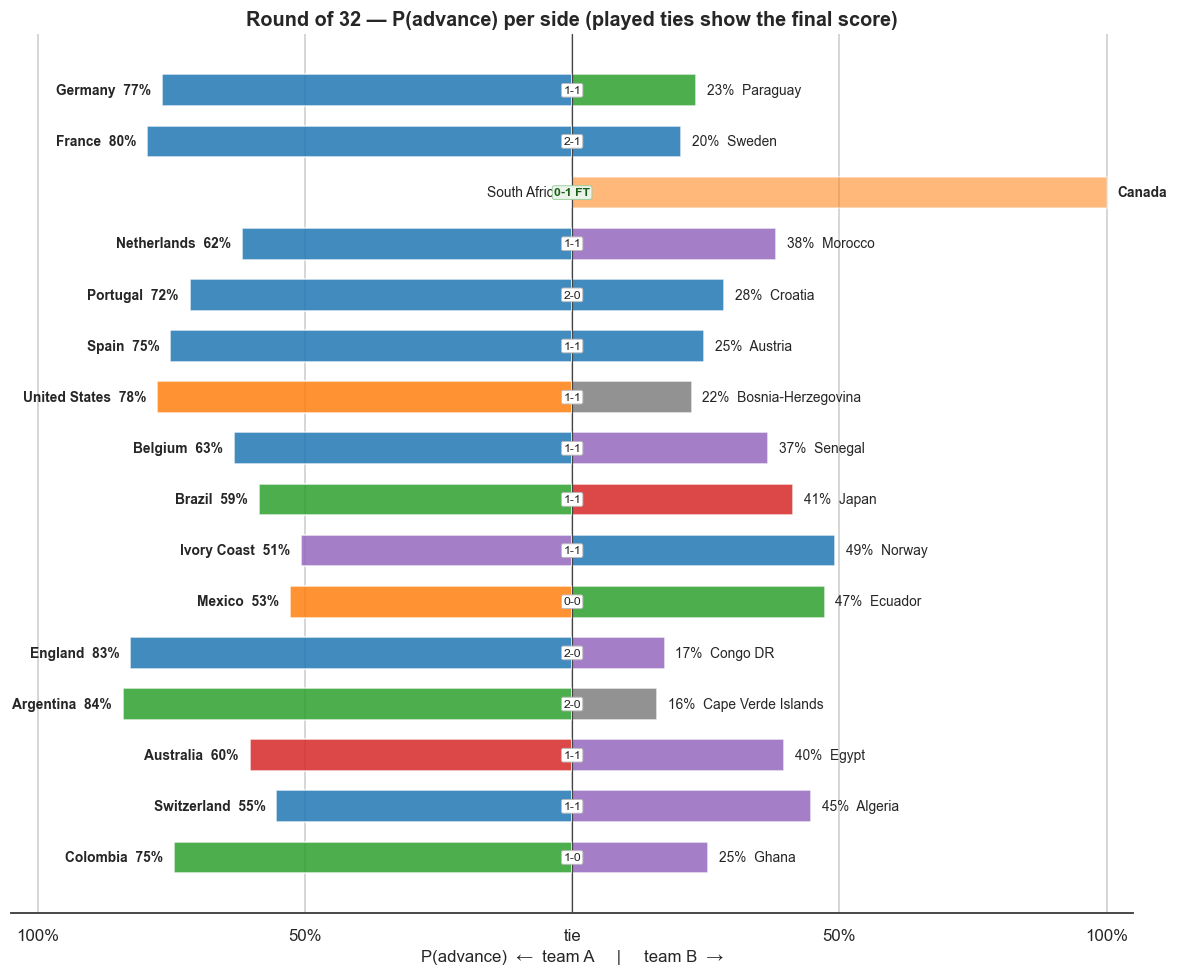

In [2]:
fig, ax = plt.subplots(figsize=(11, 9))
n = len(ties)
y = np.arange(n)[::-1]  # R32_01 at the top

for i, row in ties.iterrows():
    yy = y[i]
    done = bool(row["played"])
    ca = nbs.confederation_color(row["team_a"])
    cb = nbs.confederation_color(row["team_b"])
    alpha = 0.55 if done else 0.85  # decided ties are de-emphasised
    ax.barh(yy, -row["p_adv_a"], color=ca, alpha=alpha, height=0.62)
    ax.barh(yy, row["p_adv_b"], color=cb, alpha=alpha, height=0.62)
    fa = "bold" if row["favorite"] == row["team_a"] else "normal"
    fb = "bold" if row["favorite"] == row["team_b"] else "normal"
    la = row["team_a"] if done else f"{row['team_a']}  {row['p_adv_a']:.0%}"
    lb = row["team_b"] if done else f"{row['p_adv_b']:.0%}  {row['team_b']}"
    ax.text(-row["p_adv_a"] - 0.02, yy, la, ha="right", va="center", fontsize=9, fontweight=fa)
    ax.text(row["p_adv_b"] + 0.02, yy, lb, ha="left", va="center", fontsize=9, fontweight=fb)
    center = f"{row['result']} FT" if done else (row["scoreline"] if isinstance(row["scoreline"], str) else "")
    ax.text(0, yy, center, ha="center", va="center", fontsize=8,
            color="#1a5e1a" if done else "#222222", fontweight="bold" if done else "normal",
            bbox=dict(boxstyle="round,pad=0.15", fc="#eaf4ea" if done else "white",
                      ec="#9ccd9c" if done else "#bbbbbb", lw=0.6))

ax.axvline(0, color="#444444", lw=0.8)
ax.set_xlim(-1.05, 1.05)
ax.set_yticks([])
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_xticklabels(["100%", "50%", "tie", "50%", "100%"])
ax.set_title("Round of 32 — P(advance) per side (played ties show the final score)", fontweight="bold")
ax.set_xlabel("P(advance)  ←  team A     |     team B  →")
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 2. The title race — Monte-Carlo championship probabilities

The knockout-only simulator (seeded from the real round of 32, so every one of the 32 teams is in
play) plays the whole bracket thousands of times. The share of runs each team wins is its
championship probability.


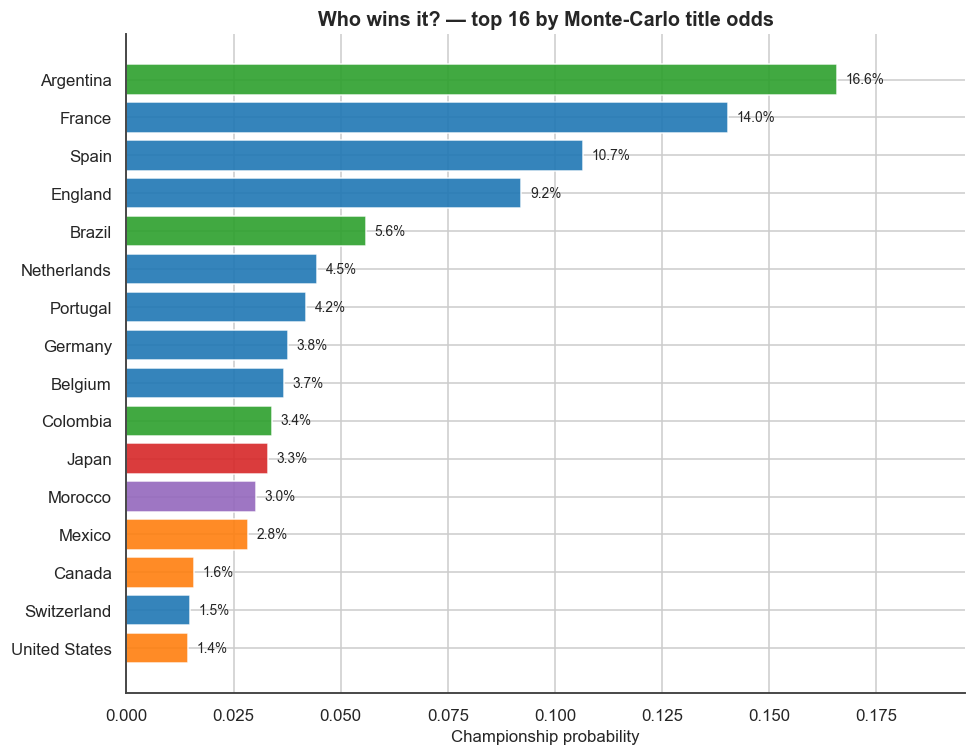

In [3]:
top = champ.head(16).iloc[::-1]
colors = [nbs.confederation_color(t) for t in top["team"]]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["team"], top["championship_prob"], color=colors, alpha=0.9)
for i, v in enumerate(top["championship_prob"]):
    ax.text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlabel("Championship probability")
ax.set_title("Who wins it? — top 16 by Monte-Carlo title odds", fontweight="bold")
ax.set_xlim(0, top["championship_prob"].max() * 1.18)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 3. How far does each team go?

`round_reached` records the **deepest** stage a team reaches in each run, so the cumulative
"reached at least round R" probability is the sum over all stages at or beyond R. The heatmap reads
left-to-right as a survival curve: P(reach R16) ≥ P(reach QF) ≥ … ≥ P(champion).


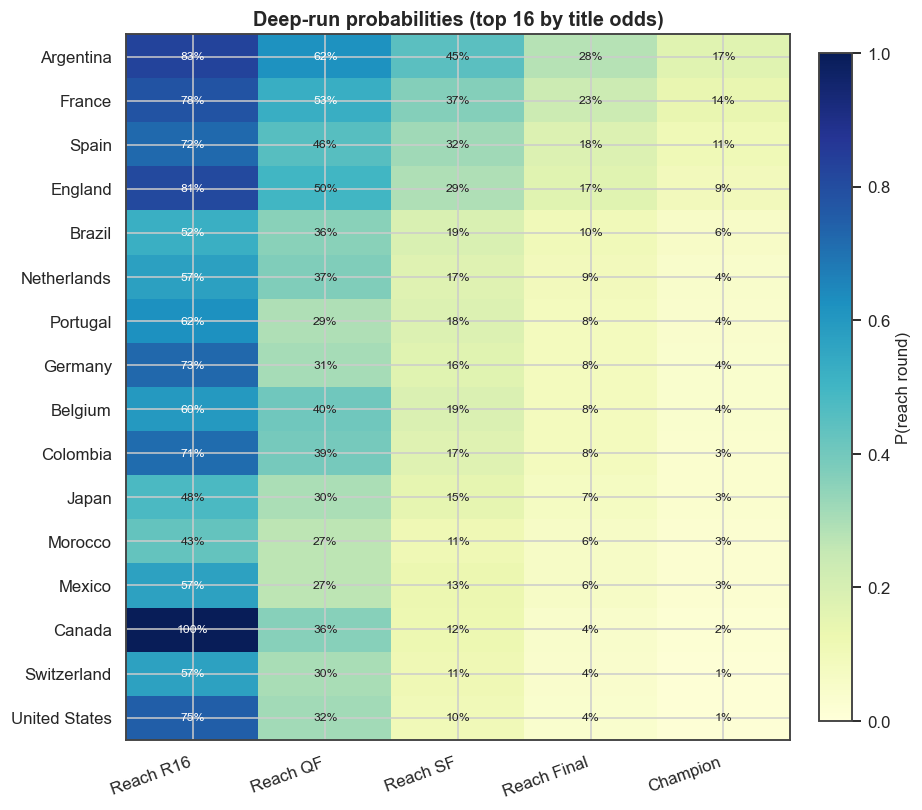

In [4]:
order = ["r32", "r16", "qf", "sf", "final", "champion"]
labels = {"r16": "Reach R16", "qf": "Reach QF", "sf": "Reach SF", "final": "Reach Final", "champion": "Champion"}
pivot = reached.pivot_table(index="team", columns="stage", values="prob", fill_value=0.0)
pivot = pivot.reindex(columns=order, fill_value=0.0)

# Cumulative: P(reach >= stage) = sum of deepest-stage probs at or beyond it.
cum = pivot[order[::-1]].cumsum(axis=1)[order[::-1]]
cum = cum[["r16", "qf", "sf", "final", "champion"]].rename(columns=labels)

top_teams = champ.head(16)["team"].tolist()
cum = cum.loc[[t for t in top_teams if t in cum.index]]

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cum.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(cum.shape[1]))
ax.set_xticklabels(cum.columns, rotation=20, ha="right")
ax.set_yticks(range(cum.shape[0]))
ax.set_yticklabels(cum.index)
for i in range(cum.shape[0]):
    for j in range(cum.shape[1]):
        v = cum.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.5 else "#222222")
ax.set_title("Deep-run probabilities (top 16 by title odds)", fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="P(reach round)")
fig.tight_layout()
plt.show()

## 4. The bracket — results so far, projection ahead

A standard single-elimination tree that updates as the tournament unfolds:

- **Played ties** (green boxes) show the **actual final score**, with the team that went through in
  bold. These come from the canonical table, so the bracket always reflects reality.
- **Upcoming ties** (blue boxes) show both teams' **win probability summing to 100%**; the favourite
  (bold) is projected through. Future matchups are the winners of the previous round, scored on a
  neutral venue with the same blended model the simulator uses (P(win) = p_home + 0.5·p_draw,
  symmetrised so the two sides sum to 100%).

So the left of the tree is history and the right is the model's projection; the boundary moves
rightward each matchday. This *modal* path (favourite at every undecided node) is distinct from the
championship probabilities above — an underdog run is likely *somewhere*, just not predictable
*where* — so the projected champion need not be the team with the highest title odds. The
**third-place play-off** beneath the final pits the two beaten semi-finalists.

2026-06-29 14:36:35,140 | src.utils.config               | INFO     | Loaded configuration from ./config/config.yaml


2026-06-29 14:36:35,627 | src.ratings.elo                | INFO     | Elo fit over 11934 matches; 304 teams rated (xi=0.0000)


2026-06-29 14:36:36,017 | src.ratings.pi_rating          | INFO     | PI Rating fit over 11934 matches (xi=0.0000)


2026-06-29 14:36:36,394 | src.ratings.form_rating        | INFO     | Form rating fit over 11934 matches


2026-06-29 14:36:36,397 | src.ratings.rating_ensemble    | INFO     | Rating ensemble fit completed


2026-06-29 14:36:36,475 | src.utils.config               | INFO     | Loaded configuration from ./config/config.yaml


2026-06-29 14:36:36,481 | src.data.squad_value_client    | INFO     | Loaded squad values: 546 snapshots, 183 teams, dates [datetime.date(2018, 6, 1), datetime.date(2022, 6, 1), datetime.date(2026, 6, 1)]


2026-06-29 14:36:36,711 | src.features.squad_value_features | INFO     | Squad-value features added (12926 matches, 100.0% from snapshots)


2026-06-29 14:36:37,474 | src.prediction.feature_builder | INFO     | Built pairwise feature matrix: 995 ordered pairs


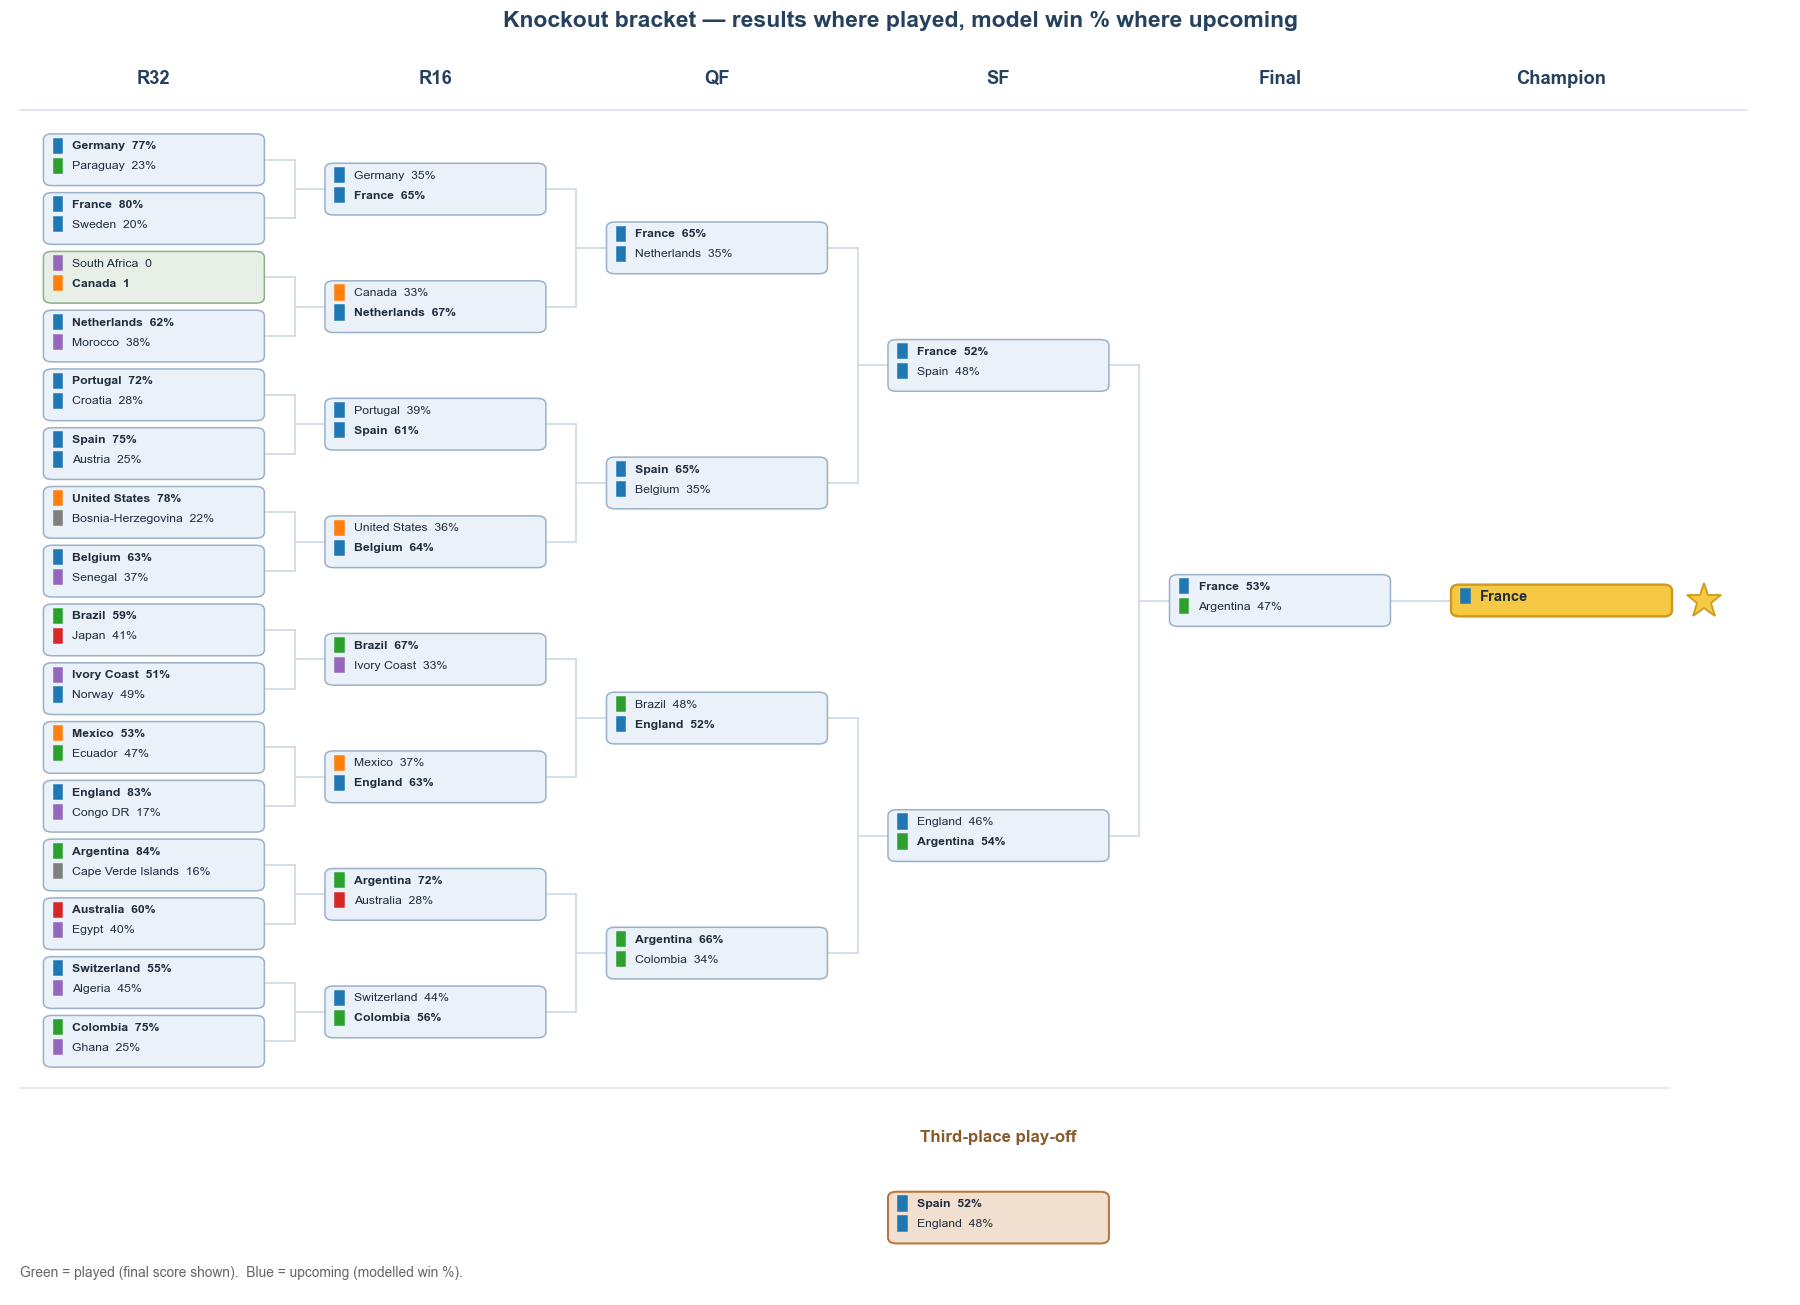

Projected champion: France
Projected third place: Spain


In [5]:
from matplotlib.patches import Rectangle
from src.ensemble.blender import BlendWeights, ProbabilityBlender
from src.models.base_model import BaseOutcomeModel
from src.models.calibration import ProbabilityCalibrator
from src.models.poisson_model import PoissonScoreModel
from src.prediction.feature_builder import build_pairwise_feature_matrix
from src.prediction.predictor import MatchPredictor
from src.utils.config import load_config
from src.utils.io import load_pickle

# --- Pairwise P(win) for any UNPLAYED matchup ----------------------------
# Future ties are scored exactly like the simulator: a neutral feature row per
# ordered team pair through the blended model, P(win) = p_home + 0.5*p_draw,
# symmetrised so the two sides sum to 1.
def _opt(loader):
    try:
        return loader()
    except FileNotFoundError:
        return None

_md = Path("models")
_pois = _opt(lambda: load_pickle(_md / "poisson_model.pkl"))
_cal = _opt(lambda: load_pickle(_md / "calibrator.pkl"))
_ens = _opt(lambda: load_pickle(_md / "rating_ensemble.pkl"))
_predictor = MatchPredictor(
    outcome_models={
        "multinomial": _opt(lambda: BaseOutcomeModel.load(_md / "multinomial_model.pkl")),
        "xgboost": _opt(lambda: BaseOutcomeModel.load(_md / "xgboost_model.pkl")),
    },
    poisson_model=_pois if isinstance(_pois, PoissonScoreModel) else None,
    elo=_ens.elo if _ens is not None else None,
    calibrator=_cal if isinstance(_cal, ProbabilityCalibrator) else None,
    blender=ProbabilityBlender(weights=BlendWeights.from_config(load_config())),
)
_teams = sorted({str(t) for t in pd.concat([ties["team_a"], ties["team_b"]]).dropna()})
_pf = build_pairwise_feature_matrix(_teams, tournament_year=2026)
_raw = {}
if not _pf.empty:
    for (a, b), row in zip(zip(_pf["team_a"].astype(str), _pf["team_b"].astype(str)),
                           _predictor.predict_proba(_pf)):
        _raw[(a, b)] = float(row[0]) + 0.5 * float(row[1])


def padv(a, b):
    """Symmetric P(a beats b) in a one-off neutral knockout match."""
    ab, ba = _raw.get((a, b)), _raw.get((b, a))
    if ab is not None and ba is not None:
        return 0.5 * (ab + 1.0 - ba)
    if ab is not None:
        return ab
    if ba is not None:
        return 1.0 - ba
    ca, cb = champ_prob.get(a, 1e-9), champ_prob.get(b, 1e-9)  # title-odds fallback
    return ca / (ca + cb)


def resolve(a, b):
    """A match dict: the actual result if the tie is played, else the prediction."""
    res = result_of(a, b)
    if res is not None:
        sa, sb, win = res
        if win is None:  # penalty shootout: winner not in the score -> model favourite
            win = a if padv(a, b) >= 0.5 else b
        return {"a": a, "b": b, "pa": 1.0 if win == a else 0.0, "pb": 1.0 if win == b else 0.0,
                "winner": win, "played": True, "score": f"{int(sa)}-{int(sb)}"}
    p = padv(a, b)
    return {"a": a, "b": b, "pa": p, "pb": 1.0 - p, "winner": a if p >= 0.5 else b,
            "played": False, "score": ""}


# --- Build each round: R32 from `ties`, later rounds from the winners ----
def _r32_match(r):
    return {"a": r["team_a"], "b": r["team_b"], "pa": r["p_adv_a"], "pb": r["p_adv_b"],
            "winner": r["favorite"], "played": bool(r["played"]), "score": r["result"]}

rounds = [[_r32_match(r) for _, r in ties.iterrows()]]
while len(rounds[-1]) > 1:
    winners = [m["winner"] for m in rounds[-1]]
    rounds.append([resolve(winners[2 * j], winners[2 * j + 1]) for j in range(len(winners) // 2)])
champion = rounds[-1][0]["winner"]

# Third-place play-off: the two beaten semi-finalists (rounds[3] = SF matches).
sf_losers = [m["b"] if m["winner"] == m["a"] else m["a"] for m in rounds[3]]
third = resolve(sf_losers[0], sf_losers[1])

# --- Geometry: one box per match, midpoint-stacked between its feeders ----
ypos = [list(np.arange(16)[::-1].astype(float))]
for r in range(1, len(rounds)):
    p = ypos[-1]
    ypos.append([(p[2 * j] + p[2 * j + 1]) / 2 for j in range(len(rounds[r]))])

xstep, box_w = 3.3, 2.55
NAVY, FILL = "#26415e", "#eaf1f8"
PLAYED_FILL, PLAYED_E = "#e7efe6", "#8fae8a"
GOLD, GOLD_E = "#f6c945", "#cf9b1c"
BRZ_FILL, BRZ_E = "#f1e0cf", "#b9743a"
EDGE, CONN, TXT = "#9bb1c7", "#cdd9e6", "#1f2d3d"
round_names = ["R32", "R16", "QF", "SF", "Final", "Champion"]

fig, ax = plt.subplots(figsize=(16.5, 12))


def box(x, y, rows, fc=FILL, ec=EDGE, lw=1.0, fs=8.0):
    """Draw a rounded box. ``rows`` = list of (text, accent_color, bold)."""
    h = 0.34 * len(rows) + 0.16
    ax.add_patch(FancyBboxPatch((x, y - h / 2), box_w, h,
                 boxstyle="round,pad=0.02,rounding_size=0.10",
                 fc=fc, ec=ec, lw=lw, zorder=3))
    for k, (txt, ac, bold) in enumerate(rows):
        ly = y + h / 2 - 0.18 - k * 0.34
        if ac is not None:
            ax.add_patch(Rectangle((x + 0.10, ly - 0.12), 0.10, 0.24, color=ac, zorder=4))
        ax.text(x + 0.32, ly, txt, fontsize=fs, va="center", color=TXT,
                fontweight="bold" if bold else "normal", zorder=5)


def match_rows(m):
    """Two rows: played ties show goals, upcoming show win%, winner bold."""
    if m["played"] and m["score"]:
        sa, sb = m["score"].split("-")
        la, lb = f"{m['a']}  {sa}", f"{m['b']}  {sb}"
    else:
        la, lb = f"{m['a']}  {m['pa']:.0%}", f"{m['b']}  {m['pb']:.0%}"
    return [(la, nbs.confederation_color(m["a"]), m["winner"] == m["a"]),
            (lb, nbs.confederation_color(m["b"]), m["winner"] == m["b"])]


def elbow(r, j, yy):
    """Connector from the two feeder matches (round r-1) to match (r, j)."""
    cx, px = (r - 1) * xstep + box_w, r * xstep
    mx = (cx + px) / 2
    cy1, cy2 = ypos[r - 1][2 * j], ypos[r - 1][2 * j + 1]
    for cy in (cy1, cy2):
        ax.plot([cx, mx], [cy, cy], color=CONN, lw=1.1, zorder=1)
    ax.plot([mx, mx], [cy1, cy2], color=CONN, lw=1.1, zorder=1)
    ax.plot([mx, px], [yy, yy], color=CONN, lw=1.1, zorder=1)


# Each round's matches (played ties tinted green; both sides sum to 100%).
for r, rnd in enumerate(rounds):
    for j, m in enumerate(rnd):
        yy = ypos[r][j]
        if r > 0:
            elbow(r, j, yy)
        box(r * xstep, yy, match_rows(m),
            fc=PLAYED_FILL if m["played"] else FILL,
            ec=PLAYED_E if m["played"] else EDGE)

# Champion node (gold) + star, fed from the final.
fy = ypos[-1][0]
chx = len(rounds) * xstep
ax.plot([(len(rounds) - 1) * xstep + box_w, chx], [fy, fy], color=CONN, lw=1.1, zorder=1)
box(chx, fy, [(f"{champion}", nbs.confederation_color(champion), True)],
    fc=GOLD, ec=GOLD_E, lw=1.6, fs=9.6)
ax.plot(chx + box_w + 0.40, fy, marker="*", markersize=24, color=GOLD,
        markeredgecolor=GOLD_E, markeredgewidth=1.2, zorder=6)

# Third-place play-off (one match box, beneath the tree).
yb = -3.0
ax.plot([-0.3, chx + box_w], [-0.8, -0.8], color="#dde4ec", lw=1.0, zorder=0)
ax.text(3 * xstep + box_w / 2, -1.7, "Third-place play-off", ha="center",
        fontsize=11, fontweight="bold", color="#8a5a2b")
box(3 * xstep, yb, match_rows(third),
    fc=PLAYED_FILL if third["played"] else BRZ_FILL, ec=PLAYED_E if third["played"] else BRZ_E, lw=1.3)

# Round headers + frame + legend.
for c, name in enumerate(round_names):
    ax.text(c * xstep + box_w / 2, 16.3, name, ha="center", fontsize=12,
            fontweight="bold", color=NAVY)
ax.plot([-0.3, chx + box_w + 0.9], [15.85, 15.85], color="#dde4ec", lw=1.2)
ax.text(-0.3, -4.0, "Green = played (final score shown).  Blue = upcoming (modelled win %).",
        fontsize=9, color="#666666")

ax.set_xlim(-0.4, chx + box_w + 1.4)
ax.set_ylim(-4.3, 16.8)
ax.axis("off")
ax.set_title("Knockout bracket — results where played, model win % where upcoming",
             fontweight="bold", fontsize=15, color=NAVY, pad=18)
fig.tight_layout()
plt.show()
print(f"Projected champion: {champion}")
print(f"Projected third place: {third['winner']}")

## 5. Takeaways

A compact, copyable summary: the favourite + P(advance) + modal scoreline for every round-of-32 tie,
and the Monte-Carlo title shortlist. Read the bars and the bracket together — the tree is the single
likeliest story, while the probabilities are the honest spread of everything that could happen.


In [6]:
print("ROUND OF 32 — result (played) or favourite + P(advance) (upcoming)")
print("=" * 68)
for _, r in ties.iterrows():
    matchup = f"{r['team_a']} vs {r['team_b']}"
    if r["played"]:
        print(f"  {matchup:<42}  ->  FT {r['result']:<5} ({r['favorite']} through)")
    else:
        sc = r["scoreline"] if isinstance(r["scoreline"], str) else "n/a"
        print(f"  {matchup:<42}  ->  {r['favorite']:<18} {r['fav_p']:.0%}  [{sc}]")

print("\nTITLE RACE — top 8 (Monte-Carlo, conditioned on played results)")
print("=" * 68)
for _, r in champ.head(8).iterrows():
    print(f"  {r['team']:<22} {r['championship_prob']:.1%}")

print(f"\nProjected (chalk) champion: {champion}")

ROUND OF 32 — result (played) or favourite + P(advance) (upcoming)
  Germany vs Paraguay                         ->  Germany            77%  [1-1]
  France vs Sweden                            ->  France             80%  [2-1]
  South Africa vs Canada                      ->  FT 0-1   (Canada through)
  Netherlands vs Morocco                      ->  Netherlands        62%  [1-1]
  Portugal vs Croatia                         ->  Portugal           72%  [2-0]
  Spain vs Austria                            ->  Spain              75%  [1-1]
  United States vs Bosnia-Herzegovina         ->  United States      78%  [1-1]
  Belgium vs Senegal                          ->  Belgium            63%  [1-1]
  Brazil vs Japan                             ->  Brazil             59%  [1-1]
  Ivory Coast vs Norway                       ->  Ivory Coast        51%  [1-1]
  Mexico vs Ecuador                           ->  Mexico             53%  [0-0]
  England vs Congo DR                         ->  England